## Zadania do samodzielnego wykonania

1.

Plik advertising.csv zawiera w każdym rzędzie informację na temat wydatków na reklamę telewizyjną, reklamową i prasową dla pojedynczego produktu oraz zyski z jego sprzedaży. Można przedstawić zyski jako funkcję $Z(w_{TV}, w_{radio}, w_{prasa})$. Proszę zaproponować architrekturę sieci neuronowej, która dokona aproksymacji tej funkcji i dokonać ewaluacji tej sieci. Proszę porównać wyniki (MSE) dla przynajmniej dwóch różnych struktur jeżeli chodzi o liczbę neuronów i dla dwóch różnych funkcji aktywacji (najlepiej relu i tanh). Proszę pamiętać o podzieleniu zbioru na dane uczące i testujące i o pilnowaniu skali danych.

2.


Proszę o wykorzystanie rzeczywistego zbioru danych medycznych (`diabetes`) z biblioteki `sklearn.datasets` (https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html), w którym celem jest przewidywanie stopnia zaawansowania choroby cukrzycowej na podstawie zestawu cech opisujących pacjenta. Proszę przeskalować dane do jednej skali i podzielić je na dane uczące i testujące. Proszę zaproponować co najmniej 5 różnych architektur sieci neuronowych, dla każdej z nich policzyć wyniki za pomocą MSE, MAPE i R^2. Dla najlepszego modelu proszę wykonać wykres porównujący wartości rzeczywiste (na osi X) i przewidywane (na osi Y). W idealnym przypadku powinny ułożyć się na prostej y=x.

Proszę skomentować, jak architektura sieci wpływa na aproksymację i zaproponować najmniejszą sieć, dla której wyniki są dla państwa zadowalające.

3.

Proszę, bazując na powyższym zbiorze danych, dla wybranych struktur sieci (np. najlepszej otrzymanej sieci), wykonać wykresy zależności ilości wykonanych przez sieć epok oraz dwóch wybranych metryk. Uzyskany wynik należy odpowiednio opisać oraz odnieść do dotychczasowych zagadnień poruszanych na zajęciach.

___________________________________
## Zadania dla chętnych

4*.

Można spróbować (już po normalizacji) zmniejszyć wymiarowość zbioru diabetes. Żeby to osiągnąć, opcją jest np. odrzucić pierwsze dwie kolumny, albo dokonać zmniejszenia wymiarowości powszechnie używanym algorytmem PCA (https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html, w dokumentacji są przykłady użycia). Wtedy można zbadać jak zmieni się działanie sieci po takim zabiegu.


___________________________________

## Materiały:

Dokumentacja:

* https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html

# Zadanie 1

In [2]:
import pandas as pd
import numpy as np


df = pd.read_csv('Advertising.csv')

df

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [5]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn import metrics
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

architectures = [(50, 50), (100, 100, 100, 100, 100)]
activations = ['relu', 'tanh']

print("Comparing different architectures and functions of activation:\n" + "-"*50)

for arch in architectures:
    for act in activations:
        network = MLPRegressor(
            solver='adam', 
            hidden_layer_sizes=arch, 
            max_iter=5000, 
            tol=0.001, 
            activation=act,
            random_state=42 
        )
        
        network.fit(X_train_scaled, y_train)
        
        y_pred = network.predict(X_test_scaled)
        mse = mean_squared_error(y_test, y_pred)
        
        print(f"Layers: {arch} | Activation: {act.ljust(4)} | MSE: {mse:.4f}")


Comparing different architectures and functions of activation:
--------------------------------------------------
Layers: (50, 50) | Activation: relu | MSE: 0.6508
Layers: (50, 50) | Activation: tanh | MSE: 0.6820
Layers: (100, 100, 100, 100, 100) | Activation: relu | MSE: 0.5681
Layers: (100, 100, 100, 100, 100) | Activation: tanh | MSE: 0.2988


# Zadanie 2

Proszę o wykorzystanie rzeczywistego zbioru danych medycznych (diabetes) z biblioteki sklearn.datasets (https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html), w którym celem jest przewidywanie stopnia zaawansowania choroby cukrzycowej na podstawie zestawu cech opisujących pacjenta. Proszę przeskalować dane do jednej skali i podzielić je na dane uczące i testujące. Proszę zaproponować co najmniej 5 różnych architektur sieci neuronowych, dla każdej z nich policzyć wyniki za pomocą MSE, MAPE i R^2. Dla najlepszego modelu proszę wykonać wykres porównujący wartości rzeczywiste (na osi X) i przewidywane (na osi Y). W idealnym przypadku powinny ułożyć się na prostej y=x.

Proszę skomentować, jak architektura sieci wpływa na aproksymację i zaproponować najmniejszą sieć, dla której wyniki są dla państwa zadowalające.

Comparing different architectures:
------------------------------------------------------------
Architecture: (10,)           | MSE: 2778.16 | MAPE: 0.3847 | R^2: 0.4756
Architecture: (50,)           | MSE: 2635.84 | MAPE: 0.3492 | R^2: 0.5025
Architecture: (50, 50)        | MSE: 9788.55 | MAPE: 0.6888 | R^2: -0.8475
Architecture: (100, 50)       | MSE: 6624.27 | MAPE: 0.5635 | R^2: -0.2503
Architecture: (100, 100, 100) | MSE: 7705.49 | MAPE: 0.5867 | R^2: -0.4544
------------------------------------------------------------
Best architecture: (50,) с R^2 = 0.5025


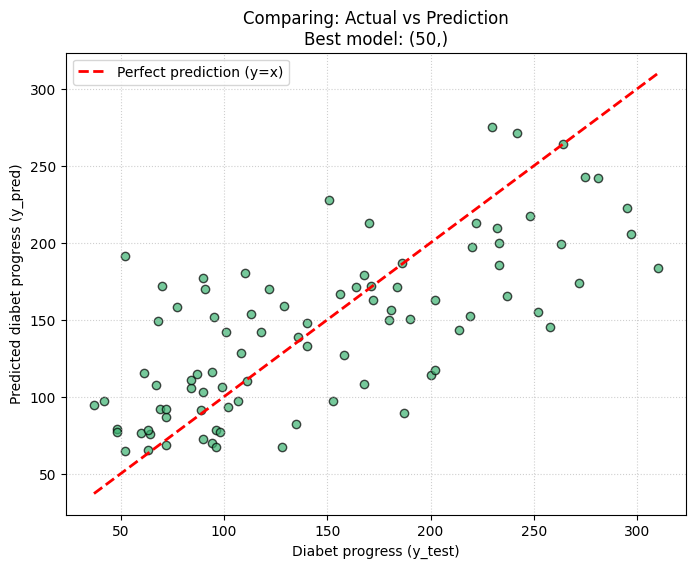

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score

diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

architectures = [
    (10,),                 
    (50,),                 
    (50, 50),              
    (100, 50),            
    (100, 100, 100)        
]

best_r2 = -float('inf')
best_y_pred = None
best_arch = None

print("Comparing different architectures:\n" + "-"*60)

for arch in architectures:
    network = MLPRegressor(
        solver='adam', 
        hidden_layer_sizes=arch, 
        max_iter=5000, 
        tol=0.001, 
        random_state=42
    )
    
    network.fit(X_train_scaled, y_train)
    
    y_pred = network.predict(X_test_scaled)
    
    mse = mean_squared_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"Architecture: {str(arch).ljust(15)} | MSE: {mse:.2f} | MAPE: {mape:.4f} | R^2: {r2:.4f}")
    
    if r2 > best_r2:
        best_r2 = r2
        best_y_pred = y_pred
        best_arch = arch

print("-" * 60)
print(f"Best architecture: {best_arch} с R^2 = {best_r2:.4f}")


plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_y_pred, alpha=0.7, color='mediumseagreen', edgecolors='k')

min_val = min(y_test.min(), best_y_pred.min())
max_val = max(y_test.max(), best_y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect prediction (y=x)')

plt.xlabel('Diabet progress (y_test)')
plt.ylabel('Predicted diabet progress (y_pred)')
plt.title(f'Comparing: Actual vs Prediction\nBest model: {best_arch}')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Zadanie 3


Proszę, bazując na powyższym zbiorze danych, dla wybranych struktur sieci (np. najlepszej otrzymanej sieci), wykonać wykresy zależności ilości wykonanych przez sieć epok oraz dwóch wybranych metryk. Uzyskany wynik należy odpowiednio opisać oraz odnieść do dotychczasowych zagadnień poruszanych na zajęciach.

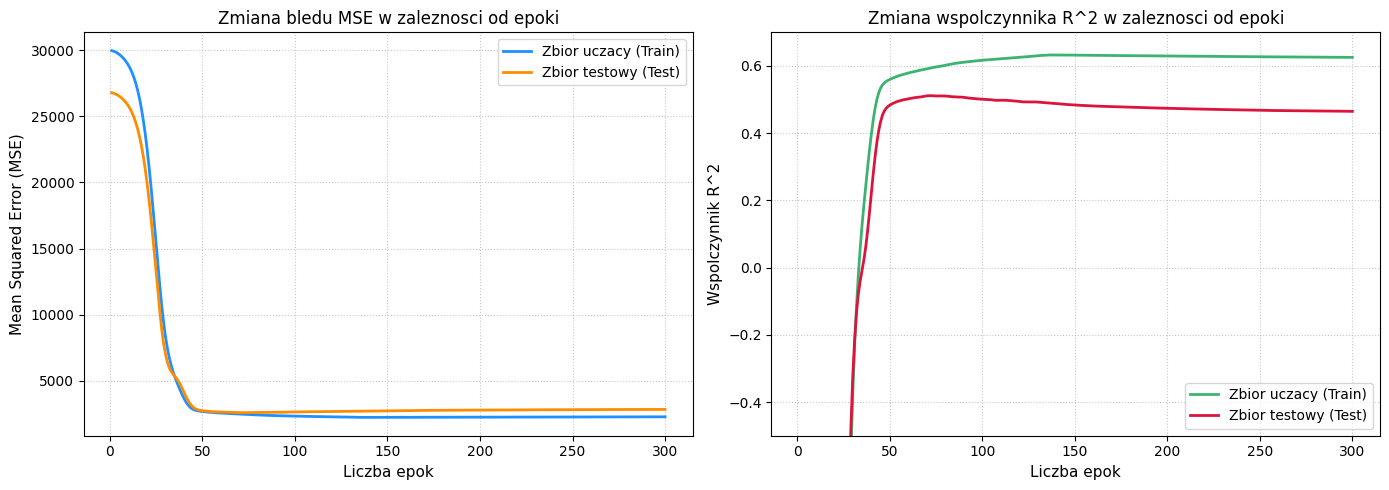

In [10]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

mlp_learning = MLPRegressor(
    solver='adam', 
    hidden_layer_sizes=best_arch, 
    warm_start=True,   
    max_iter=1,      
    random_state=42
)

epochs = 300
train_mse, test_mse = [], []
train_r2, test_r2 = [], []

for epoch in range(epochs):
    mlp_learning.fit(X_train_scaled, y_train)
    
    y_train_pred = mlp_learning.predict(X_train_scaled)
    y_test_pred = mlp_learning.predict(X_test_scaled)
    
    train_mse.append(mean_squared_error(y_train, y_train_pred))
    test_mse.append(mean_squared_error(y_test, y_test_pred))
    
    train_r2.append(r2_score(y_train, y_train_pred))
    test_r2.append(r2_score(y_test, y_test_pred))
    mlp_learning.max_iter += 1
    

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, epochs + 1), train_mse, label='Zbior uczacy (Train)', color='dodgerblue', lw=2)
ax1.plot(range(1, epochs + 1), test_mse, label='Zbior testowy (Test)', color='darkorange', lw=2)
ax1.set_title('Zmiana bledu MSE w zaleznosci od epoki', fontsize=12)
ax1.set_xlabel('Liczba epok', fontsize=11)
ax1.set_ylabel('Mean Squared Error (MSE)', fontsize=11)
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.7)

ax2.plot(range(1, epochs + 1), train_r2, label='Zbior uczacy (Train)', color='mediumseagreen', lw=2)
ax2.plot(range(1, epochs + 1), test_r2, label='Zbior testowy (Test)', color='crimson', lw=2)
ax2.set_title('Zmiana wspolczynnika R^2 w zaleznosci od epoki', fontsize=12)
ax2.set_xlabel('Liczba epok', fontsize=11)
ax2.set_ylabel('Wspolczynnik R^2', fontsize=11)
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.7)

ax2.set_ylim(-0.5, 0.7) 

plt.tight_layout()
plt.show()